# Cas 2 — Reconstruction 2D par transformée de Radon

Expérience oracle (angles connus) : comparaison sans régularisation / Tikhonov.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon
from skimage.draw import disk

np.random.seed(42)

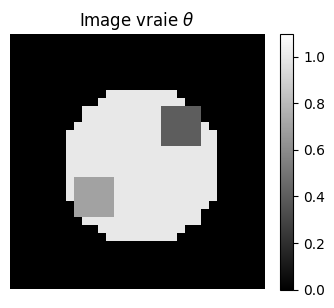

Dimension d = 1024


In [ ]:
# Fantôme 2D (analogue d'une coupe moléculaire)
size   = 32           # taille de l'image (size x size)
d      = size * size  # dimension du vecteur theta

theta_true = np.zeros((size, size))

# Disque principal (corps de la molécule)
rr, cc = disk((size//2, size//2), size//3, shape=(size, size))
theta_true[rr, cc] = 1.0

# Deux inclusions (détails internes)
rr2, cc2 = disk((size//2 - 5, size//2 + 5), size//9, shape=(size, size))
theta_true[rr2, cc2] = 0.4

rr3, cc3 = disk((size//2 + 4, size//2 - 6), size//10, shape=(size, size))
theta_true[rr3, cc3] = 0.7

theta_vec = theta_true.flatten()  # vecteur (d,)

plt.figure(figsize=(3.5, 3.5))
plt.imshow(theta_true, cmap='gray', vmin=0, vmax=1.1)
plt.colorbar(shrink=0.8); plt.title(r'Image vraie $\theta$'); plt.axis('off')
plt.tight_layout(); plt.show()
print(f"Dimension d = {d}")

In [ ]:
# Construction de la matrice de Radon A 
n_angles = 40
angles   = np.linspace(0, 180, n_angles, endpoint=False)  # angles en degrés

# Nombre de points de projection (= size avec circle=True)
n_proj = size
n_obs  = n_angles * n_proj  # nombre total de mesures

print(f"Angles : {n_angles}, points de projection : {n_proj}")
print(f"Observations totales : {n_obs}  vs  d = {d}  (rapport {n_obs/d:.1f})")
print("Construction de A (~ 1 s)...")

A = np.zeros((n_obs, d))
for k in range(d):
    ek      = np.zeros(d); ek[k] = 1.0
    proj_k  = radon(ek.reshape(size, size), theta=angles, circle=True)  # (n_proj, n_angles)
    A[:, k] = proj_k.T.flatten()  # (n_obs,)

print(f"A construit : {A.shape}")

# Conditionnement de A^T A
ATA     = A.T @ A
sv      = np.linalg.svd(ATA, compute_uv=False)
cond    = sv[0] / sv[-1]
print(f"Conditionnement de A^T A : {cond:.2e}  (Cas 1 : 1.0)")

Angles : 40, points de projection : 32
Observations totales : 1280  vs  d = 1024  (rapport 1.2)
Construction de A (~ 1 s)...


/Users/arthurconche/Desktop/projet-M1/.venv/lib/python3.14/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


A construit : (1280, 1024)
Conditionnement de A^T A : 1.50e+06  (Cas 1 : 1.0)


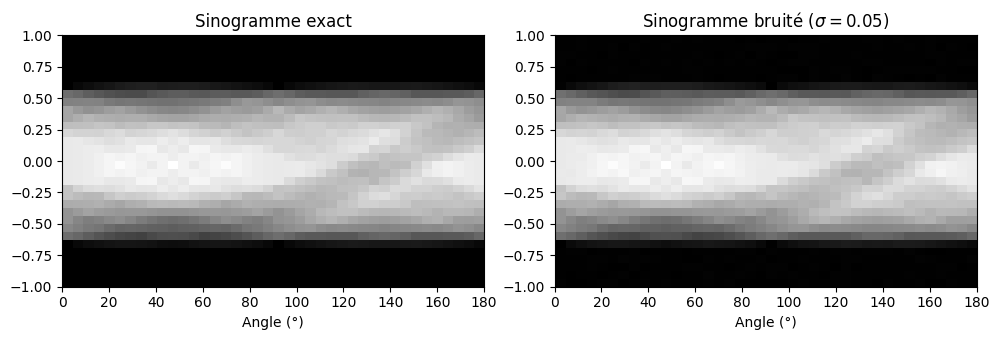

In [ ]:
# Observations bruitées 
sigma = 0.05  # faible bruit — mais le mauvais conditionnement suffira à tout dégrader

Y   = A @ theta_vec + sigma * np.random.randn(n_obs)
ATY = A.T @ Y

# Sinogramme (n_angles * n_proj) pour visualisation
sinogram_true   = (A @ theta_vec).reshape(n_angles, n_proj)
sinogram_noisy  = Y.reshape(n_angles, n_proj)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.imshow(sinogram_true.T,  aspect='auto', cmap='gray',
           extent=[0, 180, -1, 1])
ax1.set_title('Sinogramme exact'); ax1.set_xlabel('Angle (°)')
ax2.imshow(sinogram_noisy.T, aspect='auto', cmap='gray',
           extent=[0, 180, -1, 1])
ax2.set_title(f'Sinogramme bruité ($\\sigma={sigma}$)'); ax2.set_xlabel('Angle (°)')
plt.tight_layout(); plt.show()

In [ ]:
# Reconstruction sans régularisation
theta_unreg = np.linalg.lstsq(ATA, ATY, rcond=1e-10)[0]
err_unreg   = np.linalg.norm(theta_unreg - theta_vec) / np.linalg.norm(theta_vec)
print(f"Erreur sans régularisation : {err_unreg:.4f}")

# Reconstruction avec Tikhonov
lam_opt   = 150
theta_reg = np.linalg.solve(ATA + lam_opt * sigma**2 * np.eye(d), ATY)
err_reg   = np.linalg.norm(theta_reg - theta_vec) / np.linalg.norm(theta_vec)
print(f"Erreur Tikhonov (lambda={lam_opt}) : {err_reg:.4f}")

Erreur sans régularisation : 0.3298
Erreur Tikhonov (lambda=150) : 0.0690


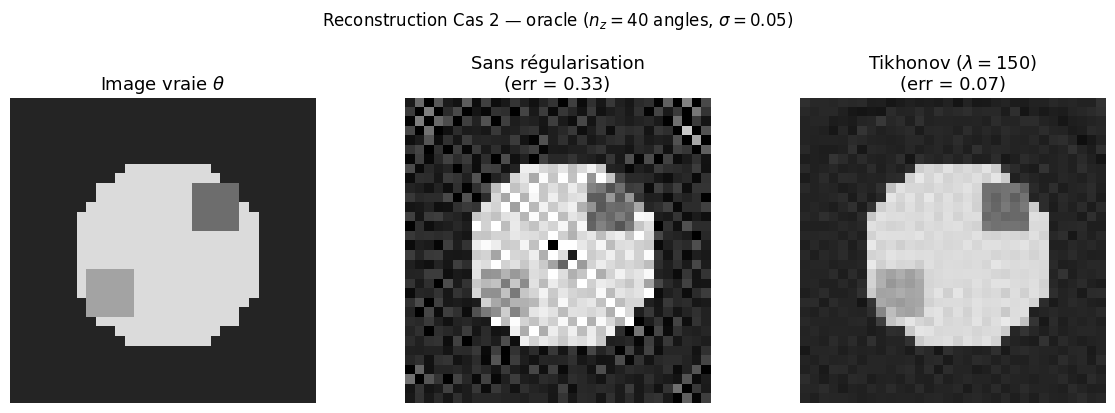

In [ ]:
# Figure principale : comparaison des trois reconstructions
vmin, vmax = -0.2, 1.2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(theta_true,                      cmap='gray', vmin=vmin, vmax=vmax)
axes[0].set_title(r'Image vraie $\theta$',      fontsize=13)
axes[0].axis('off')

axes[1].imshow(theta_unreg.reshape(size, size), cmap='gray', vmin=vmin, vmax=vmax)
axes[1].set_title(f'Sans régularisation\n'
                  f'(err = {err_unreg:.2f})',   fontsize=13)
axes[1].axis('off')

axes[2].imshow(theta_reg.reshape(size, size),   cmap='gray', vmin=vmin, vmax=vmax)
axes[2].set_title(f'Tikhonov ($\\lambda = {lam_opt}$)\n'
                  f'(err = {err_reg:.2f})',      fontsize=13)
axes[2].axis('off')

plt.suptitle(f'Reconstruction Cas 2 — oracle ($n_z = {n_angles}$ angles, '
             f'$\\sigma = {sigma}$)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../figures/reconstruction_2d.pdf', bbox_inches='tight')
plt.show()

lambda* = 137.382  (erreur min = 0.0690)


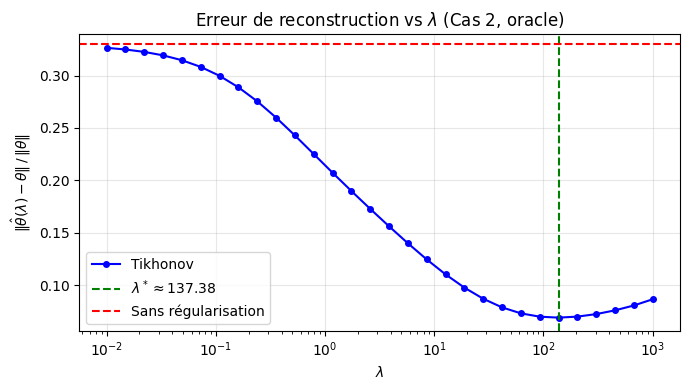

In [ ]:
# Erreur de reconstruction en fonction de lambda
lambdas    = np.logspace(-2, 3, 30)
errors_lam = []

for lam in lambdas:
    th  = np.linalg.solve(ATA + lam * sigma**2 * np.eye(d), ATY)
    errors_lam.append(np.linalg.norm(th - theta_vec) / np.linalg.norm(theta_vec))

errors_lam = np.array(errors_lam)
idx_opt    = np.argmin(errors_lam)
lam_star   = lambdas[idx_opt]
print(f"lambda* = {lam_star:.3f}  (erreur min = {errors_lam[idx_opt]:.4f})")

# Erreur sans régularisation (lambda -> 0)
err_0 = np.linalg.norm(
    np.linalg.lstsq(ATA, ATY, rcond=1e-10)[0] - theta_vec
) / np.linalg.norm(theta_vec)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(lambdas, errors_lam, 'b-o', ms=4, label='Tikhonov')
ax.axvline(lam_star, color='g', linestyle='--',
           label=rf'$\lambda^* \approx {lam_star:.2f}$')
ax.axhline(err_0, color='r', linestyle='--', label='Sans régularisation')
ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\|\hat\theta(\lambda) - \theta\| \,/\, \|\theta\|$')
ax.set_title(r'Erreur de reconstruction vs $\lambda$ (Cas 2, oracle)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/erreur_reg_cas2.pdf', bbox_inches='tight')
plt.show()

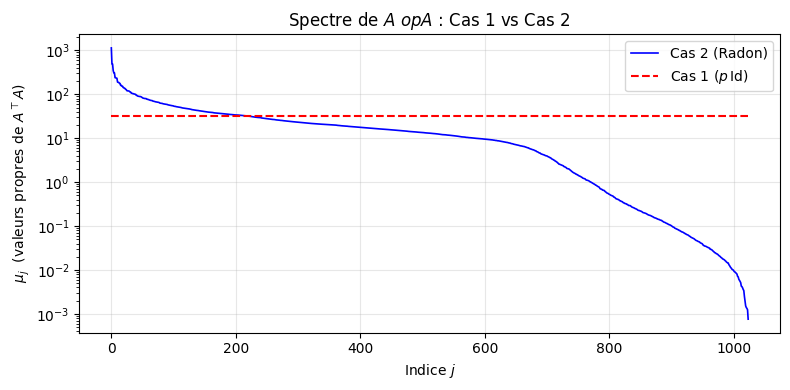

Cas 1  — cond(A^T A) = 1.00
Cas 2  — cond(A^T A) = 1.50e+06


In [ ]:
# Valeurs propres de A^T A : visualisation du mauvais conditionnement 

sv_cas2 = np.sort(sv)[::-1]           
sv_cas1 = np.full(d, float(size))     # Phi(z)^T Phi(z) = p * Id

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(sv_cas2,           'b-', lw=1.2, label='Cas 2 (Radon)')
ax.semilogy(sv_cas1,           'r--', lw=1.5, label=r'Cas 1 ($p\,\mathrm{Id}$)')
ax.set_xlabel('Indice $j$')
ax.set_ylabel(r'$\mu_j$  (valeurs propres de $A^\top A$)')
ax.set_title('Spectre de $A^\top A$ : Cas 1 vs Cas 2')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/spectre_ATA.pdf', bbox_inches='tight')
plt.show()
print(f"Cas 1  — cond(A^T A) = 1.00")
print(f"Cas 2  — cond(A^T A) = {sv[0]/sv[-1]:.2e}")